# PERSONAL PROJECT: NBA RESULT PREDICTION <br>
In this project, I have implemented the NBA dataset (2012 - 2024) from Kaggle (https://www.kaggle.com/datasets/kevinpickelman/nba-data-2012-2024/data), which includes statistics of each match with 32 columns and 31340 entries in each column. <br>
Furthermore, I created a radar chart to compare the team's average with the league's average in a season, transformed data using Yeo-Johnson method, trained and splited dataset using Random Forest and XGBoost, used RandomizedSearchCV to reduce overfitting in the XGBoost model, and produced the feature importance graphs and confusion matrix.

In [1]:
#Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import math 
from typing import List, Dict, Union

import shap
from scipy import stats
from scipy.stats import boxcox
from statsmodels.stats.proportion import proportions_ztest
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from statsmodels.formula.api import ols
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections import register_projection
from matplotlib.projections.polar import PolarAxes
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D

In [2]:
# Read the file, count number of data and find out datatype of each column
df = pd.read_csv('final_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31340 entries, 0 to 31339
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GAME_ID            31340 non-null  int64  
 1   TEAM_ID            31340 non-null  int64  
 2   TEAM_NAME          31340 non-null  object 
 3   TEAM_ABBREVIATION  31340 non-null  object 
 4   TEAM_CITY          31340 non-null  object 
 5   HOME_TEAM          31330 non-null  object 
 6   MIN                31340 non-null  object 
 7   FGM                31340 non-null  int64  
 8   FGA                31340 non-null  int64  
 9   FG_PCT             31340 non-null  float64
 10  FG3M               31340 non-null  int64  
 11  FG3A               31340 non-null  int64  
 12  FG3_PCT            31340 non-null  float64
 13  FTM                31340 non-null  int64  
 14  FTA                31340 non-null  int64  
 15  FT_PCT             31340 non-null  float64
 16  OREB               313

In [ ]:
# change data type of GAME_ID and TEAM_ID to object, MIN to int64
df['GAME_ID'] = df['GAME_ID'].astype('object')
df['TEAM_ID']  = df['TEAM_ID'].astype('object')
df['MIN'] = df['MIN'].str.split(':').str[0].astype(int)

In [5]:
# drop duplicates
duplicates = df[df.duplicated()]
print(f"Number of duplicate rows in the dataset: {duplicates.shape[0]}")

# crop all duplicated rows
df = df.drop_duplicates()
print("New shape:", df.shape)

Number of duplicate rows in the dataset: 0
New shape: (31340, 32)


In [6]:
# Check unique values
for col in df.columns:
    print(f"Column: {col}")
    print(df[col].unique())
    print("-" * 40)
print()

Column: GAME_ID
[21200001 21200002 21200003 ... 22401228 22401229 22401230]
----------------------------------------
Column: TEAM_ID
[1610612764 1610612739 1610612748 1610612738 1610612747 1610612742
 1610612761 1610612754 1610612743 1610612755 1610612745 1610612765
 1610612758 1610612741 1610612740 1610612759 1610612762 1610612744
 1610612756 1610612763 1610612746 1610612757 1610612752 1610612751
 1610612760 1610612766 1610612753 1610612749 1610612737 1610612750]
----------------------------------------
Column: TEAM_NAME
['Wizards' 'Cavaliers' 'Heat' 'Celtics' 'Lakers' 'Mavericks' 'Raptors'
 'Pacers' 'Nuggets' '76ers' 'Rockets' 'Pistons' 'Kings' 'Bulls' 'Hornets'
 'Spurs' 'Jazz' 'Warriors' 'Suns' 'Grizzlies' 'Clippers' 'Trail Blazers'
 'Knicks' 'Nets' 'Thunder' 'Bobcats' 'Magic' 'Bucks' 'Hawks'
 'Timberwolves' 'Pelicans']
----------------------------------------
Column: TEAM_ABBREVIATION
['WAS' 'CLE' 'MIA' 'BOS' 'LAL' 'DAL' 'TOR' 'IND' 'DEN' 'PHI' 'HOU' 'DET'
 'SAC' 'CHI' 'NOH' 'SAS' 

In [7]:
df.describe()

,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,...,TO,PF,PTS,PLUS_MINUS,EFG_PCT,PIE,COVID_FLAG,RESULT,SEASON,WIN_PCT
count,31340.000000,31340.000000,31340.000000,31340.000000,31340.000000,31340.000000,31340.000000,31340.000000,31340.000000,31340.000000,...,31340.000000,31340.000000,31340.000000,31340.000000,31340.000000,31340.000000,31340.000000,31340.000000,31340.000000,31340.000000
mean,241.636886,39.891034,86.543969,0.461813,10.644161,29.662444,0.357244,17.351500,22.583344,0.768939,...,13.546554,19.895756,107.777728,0.000000,0.415862,49.993618,0.136503,0.500000,17.970325,50.078217
std,7.158697,5.376204,7.535348,0.055319,4.232941,8.901290,0.093002,5.946258,7.257164,0.103103,...,3.861837,4.297284,13.470762,14.429973,0.072997,8.861399,0.343327,0.500008,3.773064,18.205477
min,240.000000,19.000000,60.000000,0.269000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,4.000000,58.000000,-73.000000,0.190000,2.900000,0.000000,0.000000,12.000000,0.000000
25%,240.000000,36.000000,81.000000,0.424000,8.000000,23.000000,0.296000,13.000000,17.000000,0.704000,...,11.000000,17.000000,98.000000,-9.000000,0.370000,43.840000,0.000000,0.000000,15.000000,38.157895
50%,240.000000,40.000000,86.000000,0.461000,10.000000,30.000000,0.356000,17.000000,22.000000,0.778000,...,13.000000,20.000000,108.000000,0.000000,0.410000,50.000000,0.000000,0.500000,18.000000,50.000000
75%,240.000000,43.000000,91.000000,0.500000,13.000000,36.000000,0.417000,21.000000,27.000000,0.840000,...,16.000000,23.000000,117.000000,9.000000,0.450000,56.160000,0.000000,1.000000,21.000000,61.904762
max,340.000000,65.000000,129.000000,0.689000,29.000000,70.000000,0.842000,52.000000,64.000000,1.000000,...,31.000000,42.000000,176.000000,73.000000,0.780000,97.100000,1.000000,1.000000,24.000000,100.000000


In [8]:
# 10 missing values in HOME_TEAM
df.isnull().sum()

GAME_ID               0
TEAM_ID               0
TEAM_NAME             0
TEAM_ABBREVIATION     0
TEAM_CITY             0
HOME_TEAM            10
MIN                   0
FGM                   0
FGA                   0
FG_PCT                0
FG3M                  0
FG3A                  0
FG3_PCT               0
FTM                   0
FTA                   0
FT_PCT                0
OREB                  0
DREB                  0
REB                   0
AST                   0
STL                   0
BLK                   0
TO                    0
PF                    0
PTS                   0
PLUS_MINUS            0
EFG_PCT               0
PIE                   0
COVID_FLAG            0
RESULT                0
SEASON                0
WIN_PCT               0
dtype: int64

In [9]:
# replace nan in HOME_TEAM with np.nan
df['HOME_TEAM'] = df['HOME_TEAM'].replace(r'^\s*$', np.nan, regex=True)
# create dataFrame that shows home team, team name and team id 
mapping = (
    df
    # find the most frequent Home team per combination of team name and team id
    .groupby(['TEAM_ID','TEAM_NAME'])['HOME_TEAM']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    .reset_index()
)

# merge this new dataFrame into the dataset to fill missing values in home team with matching value
df = df.merge(
    mapping,
    on=['TEAM_ID', 'TEAM_NAME'],
    how='left',
    suffixes=('', '_from_chain')
)
df['HOME_TEAM'] = df['HOME_TEAM'].fillna(df['HOME_TEAM_from_chain'])

# drop the dataFrame
df.drop(columns=['HOME_TEAM_from_chain'], inplace=True)

In [10]:
# no more outliers left.
df.isnull().sum()

GAME_ID              0
TEAM_ID              0
TEAM_NAME            0
TEAM_ABBREVIATION    0
TEAM_CITY            0
HOME_TEAM            0
MIN                  0
FGM                  0
FGA                  0
FG_PCT               0
FG3M                 0
FG3A                 0
FG3_PCT              0
FTM                  0
FTA                  0
FT_PCT               0
OREB                 0
DREB                 0
REB                  0
AST                  0
STL                  0
BLK                  0
TO                   0
PF                   0
PTS                  0
PLUS_MINUS           0
EFG_PCT              0
PIE                  0
COVID_FLAG           0
RESULT               0
SEASON               0
WIN_PCT              0
dtype: int64

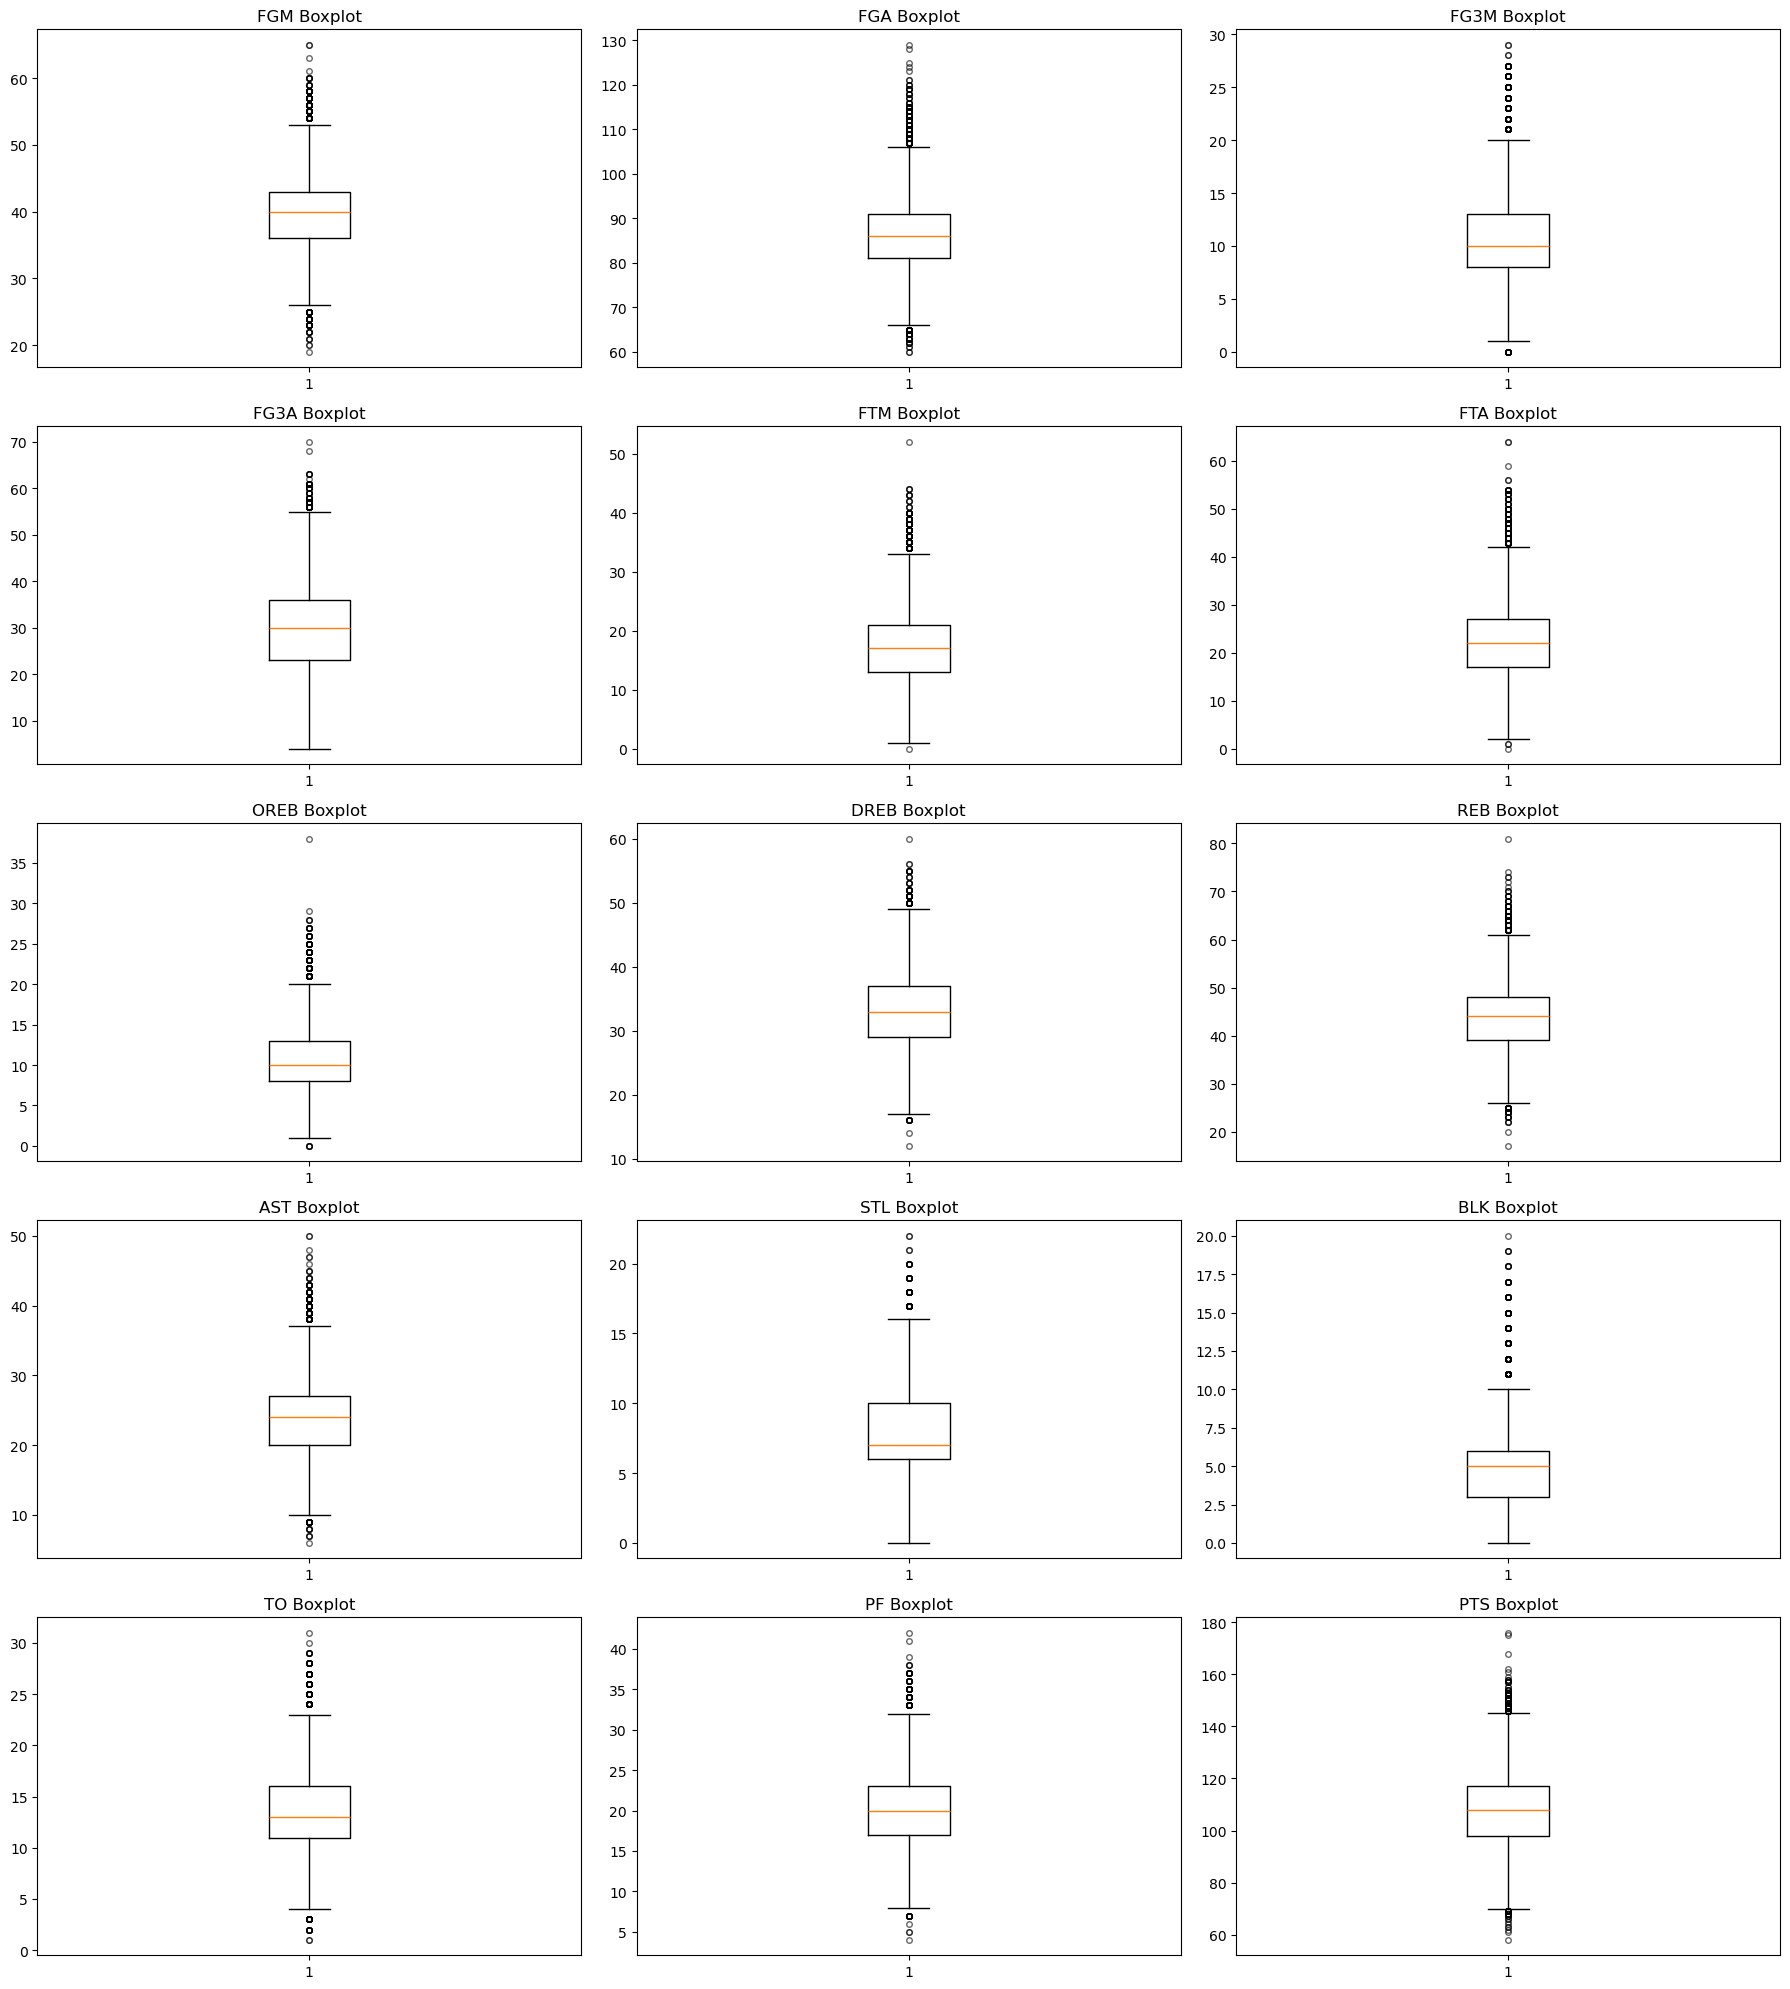

In [11]:
# boxplots for columns. Has many outliers in each column.
cols_to_check = ['FGM','FGA','FG3M','FG3A','FTM', 'FTA', 'OREB','DREB','REB','AST','STL','BLK','TO','PF','PTS']
ncols = 3
nrows = math.ceil(len(cols_to_check)/ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4 * nrows), sharey=False)
axes = axes.flatten()

for i, col in enumerate(cols_to_check):
    ax = axes[i]
    ax.boxplot(df[col].dropna(), flierprops=dict(marker='o', markersize=4, alpha=0.6))
    ax.set_title(f"{col} Boxplot")
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

# skewness check result:
- Most columns have skewness below 0.5, with the highest being BLK at 0.665746. we should transform this column to reduce its skewness and improve model reliability later.
- Columns with higher than 0.4 skewness: FTM, FTA, OREB, STL -> transform this aswell.
- Other columns that have skewness <= 0.3 -> no need to transform the data since they are close to symmetry and normal distribution.

In [12]:
# check skewness for the cols to check
skewness = df[cols_to_check].skew()
print(skewness)

FGM     0.152221
FGA     0.231798
FG3M    0.380372
FG3A    0.132425
FTM     0.404134
FTA     0.416154
OREB    0.460989
DREB    0.173146
REB     0.203701
AST     0.237938
STL     0.409920
BLK     0.665746
TO      0.277324
PF      0.271108
PTS     0.123441
dtype: float64


In [13]:
# transform BLK, FTM, FTA, OREB, STL, EFG_PCT and FT_PCT. Use Yeo-Johnson.
cols_to_transform = ['FTM', 'FTA', 'OREB', 'STL', 'BLK', 'EFG_PCT', 'FT_PCT']

df_transformed = df.copy()

for col in cols_to_transform:
    new_col = f'{col}_YJ'
    pt = PowerTransformer(method='yeo-johnson')
    df_transformed[new_col] = pt.fit_transform(df[[col]])
    
transformed_cols = [f'{col}_YJ' for col in cols_to_transform]
transformed_skew = df_transformed[transformed_cols].skew()
print(transformed_skew)

FTM_YJ       -0.001988
FTA_YJ        0.003250
OREB_YJ      -0.001007
STL_YJ        0.000145
BLK_YJ       -0.003244
EFG_PCT_YJ   -0.003779
FT_PCT_YJ     0.000173
dtype: float64


In [14]:
# check skewness for all numerical column before visusalization
skew_all_sorted = df_transformed.skew(numeric_only=True).sort_values(ascending=False)
print(skew_all_sorted)

MIN           5.173467
COVID_FLAG    2.117632
EFG_PCT       0.824332
BLK           0.665746
OREB          0.460989
FTA           0.416154
STL           0.409920
FTM           0.404134
FG3M          0.380372
TO            0.277324
PF            0.271108
AST           0.237938
FGA           0.231798
REB           0.203701
DREB          0.173146
FGM           0.152221
FG3A          0.132425
PTS           0.123441
FG3_PCT       0.098578
FG_PCT        0.096032
SEASON        0.022224
FTA_YJ        0.003250
FT_PCT_YJ     0.000173
STL_YJ        0.000145
PLUS_MINUS    0.000000
RESULT        0.000000
OREB_YJ      -0.001007
FTM_YJ       -0.001988
BLK_YJ       -0.003244
EFG_PCT_YJ   -0.003779
PIE          -0.004293
WIN_PCT      -0.063002
FT_PCT       -0.407447
dtype: float64


# SECTION 2: VISUALIZATION

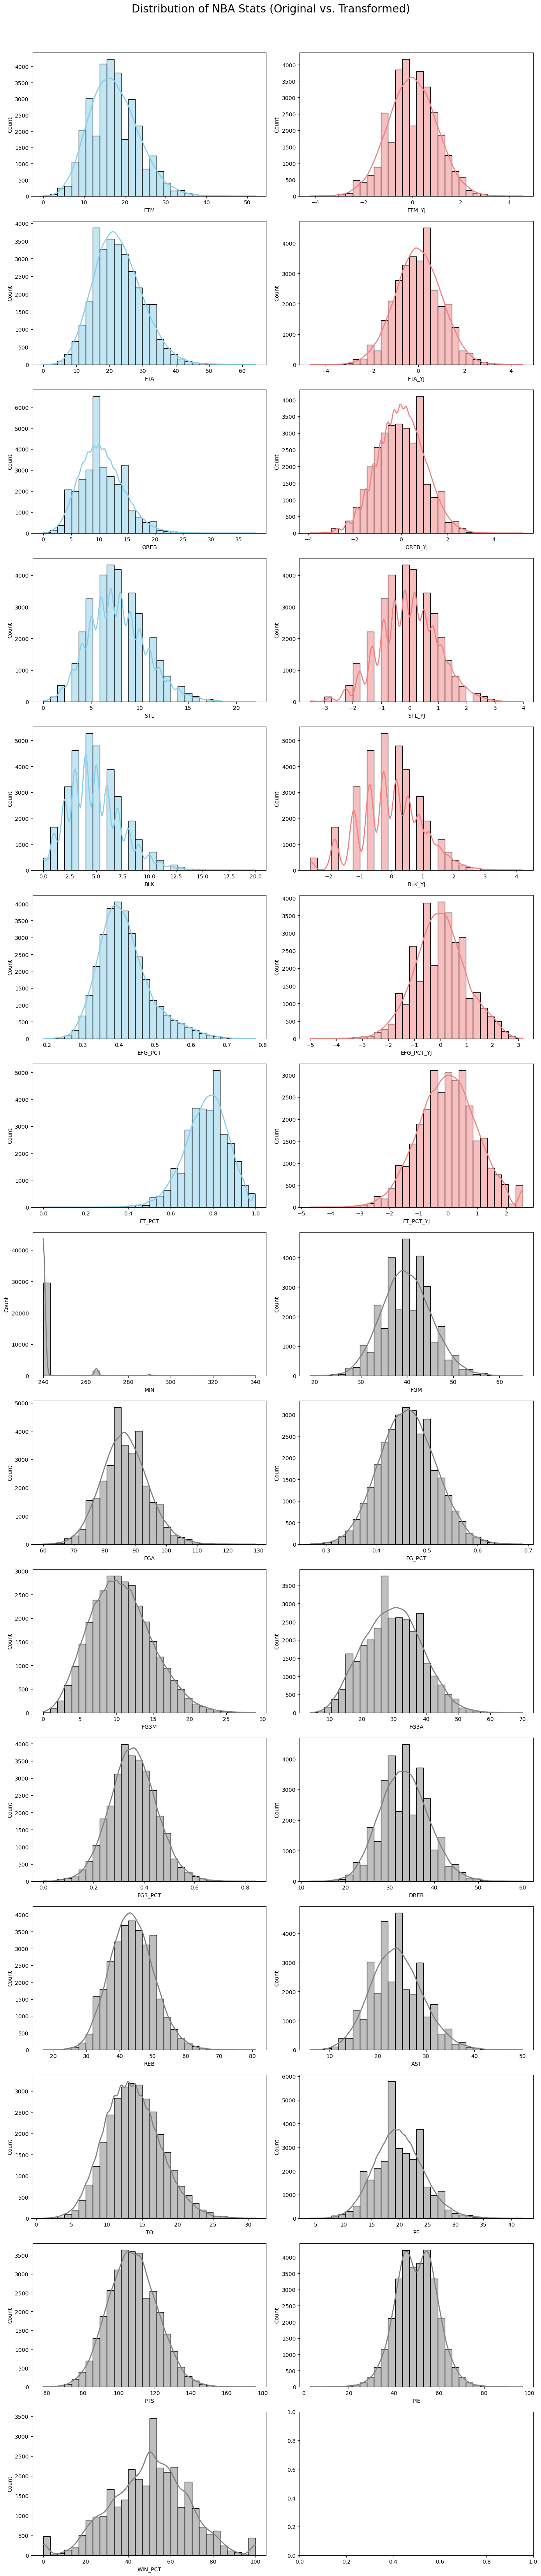

In [ ]:
# define the transformed columns and their original names
TRANSFORMED_MAP = {
    'FTM': 'FTM_YJ',
    'FTA': 'FTA_YJ',
    'OREB': 'OREB_YJ',
    'STL': 'STL_YJ',
    'BLK': 'BLK_YJ',
    'EFG_PCT': 'EFG_PCT_YJ',
    'FT_PCT' : 'FT_PCT_YJ' 
}

# identify the columns that have original and transformed versions
original_cols_to_compare = list(TRANSFORMED_MAP.keys())
numeric_cols = df_transformed.select_dtypes(include=['int64', 'float64']).columns.tolist()
exclude_cols = ['PLUS_MINUS', 'SEASON', 'COVID_FLAG', 'RESULT']

# filter out all transformed columns and the other excluded columns
other_original_cols = [
    col for col in numeric_cols 
    if col not in TRANSFORMED_MAP.values() and col not in exclude_cols
    and col not in original_cols_to_compare
]

# create a list of all columns to be plotted
all_plots_data = []
for orig_col in original_cols_to_compare:
    trans_col = TRANSFORMED_MAP[orig_col]
    all_plots_data.append((orig_col, "Original"))
    all_plots_data.append((trans_col, "Transformed"))

for col in other_original_cols:
    all_plots_data.append((col, "Untransformed"))

num_plots = len(all_plots_data)
n_cols = 2 
n_rows = math.ceil(num_plots / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4.5 * n_rows))
axes = axes.flatten()

fig.suptitle("Distribution of NBA Stats (Original vs. Transformed)", 
             fontsize=20, y=0.98)

for i, (col_name, col_type) in enumerate(all_plots_data):
    if col_type == "Original":
        color = 'skyblue'
        kde_color = 'blue'
    elif col_type == "Transformed":
        color = 'lightcoral'
        kde_color = 'red'
    else: 
        color = 'grey'
        kde_color = 'black'

    sns.histplot(df_transformed[col_name], 
                 bins=30, 
                 kde=True, 
                 line_kws={'color': kde_color, 'linestyle': '-', 'linewidth': 2}, 
                 ax=axes[i],
                 color=color) 
    if col_type != "Untransformed":
        title = f"{col_name} ({col_type})"
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [16]:
# create radar chart 
STATS_TO_COMPARE = [
    'FGA', 'FGM', 'FG3M', 'FG3A', 'FTA', 'FTM',
    'REB', 'AST', 'STL', 'BLK', 'TO', 'PF', 'PTS'
] 
def seasonal_avg(df: pd.DataFrame, stats_cols: List[str]) -> pd.DataFrame:
    season_average = df.groupby('SEASON')[stats_cols].mean().reset_index()
    return season_average

def normalize_data(
    df: pd.DataFrame, 
    stats_cols: List[str],
    min_val: float = 0.0,
    max_val: float = 100.0
) -> pd.DataFrame:
    
    # applies Min-Max normalization to the specified stat columns    
    df_normalized = df.copy()
    
    for stat in stats_cols:
        # calculate min/max across the entire dataset for that stat
        data_min = df_normalized[stat].min()
        data_max = df_normalized[stat].max()
        
        # cpply min-max scaling: (X - min) / (max - min) * (new_max - new_min) + new_min
        if data_max > data_min:
            df_normalized[stat] = ((df_normalized[stat] - data_min) / (data_max - data_min)) * (max_val - min_val) + min_val
        else:
            # handle case where all values are the same (set to midpoint of 0-100 range)
            df_normalized[stat] = (max_val + min_val) / 2
            
    return df_normalized

def get_normalized_radar_data(
    df_normalized: pd.DataFrame, 
    team_name: str, 
    season: int, 
    stats_cols: List[str]
) -> Dict[str, Union[str, List[str], List[float]]]:
    team_data = df_normalized[(df_normalized['TEAM_ABBREVIATION'] == team_name) & (df_normalized['SEASON'] == season)]
    if team_data.empty: return {}
    team_values = team_data[stats_cols].mean().tolist()
    
    # get league average data
    league_avg_normalized = df_normalized[df_normalized['SEASON'] == season][stats_cols].mean().tolist()
    labels = [label for label in stats_cols]
    return {
        'team': team_name,
        'season': season,
        'labels': labels,
        'team_values': team_values,
        'league_avg_values': league_avg_normalized
    } 

def radar_factory(num_vars, frame = 'circle'):
    theta = np.linspace(0, 2 * np.pi, num_vars, endpoint= False)
    
    class RadarTransform(PolarAxes.PolarTransform):
        def transform_path_non_affine(self, path):
            if path._interpolation_steps > 1:
                path = path.interpolated(num_vars)
            return Path(self.transform(path.vertices), path.codes)
    
    class RadarAxes(PolarAxes):
        name = 'radar'
        PolarTransform = RadarTransform
        
        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            self.set_theta_zero_location('N')

        def fill(self, *args, closed=True, **kwargs):
            return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)
            return lines

        def _close_line(self, line):
            x, y = line.get_data()
            if x[0] != x[-1]:
                x = np.append(x, x[0])
                y = np.append(y, y[0])
                line.set_data(x, y)

        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)

        def _gen_axes_patch(self):
            if frame == 'circle':
                return Circle((0.5, 0.5), 0.5)
            elif frame == 'polygon':
                return RegularPolygon((0.5, 0.5), num_vars,
                                     radius=.5, edgecolor="k")
            else:
                raise ValueError("Unknown value for 'frame': %s" % frame)

        def _gen_axes_spines(self):
            if frame == 'circle':
                return super()._gen_axes_spines()
            elif frame == 'polygon':
                spine = Spine(axes=self,
                              spine_type='circle',
                              path=Path.unit_regular_polygon(num_vars))
                spine.set_transform(Affine2D().scale(.5).translate(.5, .5)
                                    + self.transAxes)
                return {'polar': spine}
            else:
                raise ValueError("Unknown value for 'frame': %s" % frame)

    register_projection(RadarAxes)
    return theta

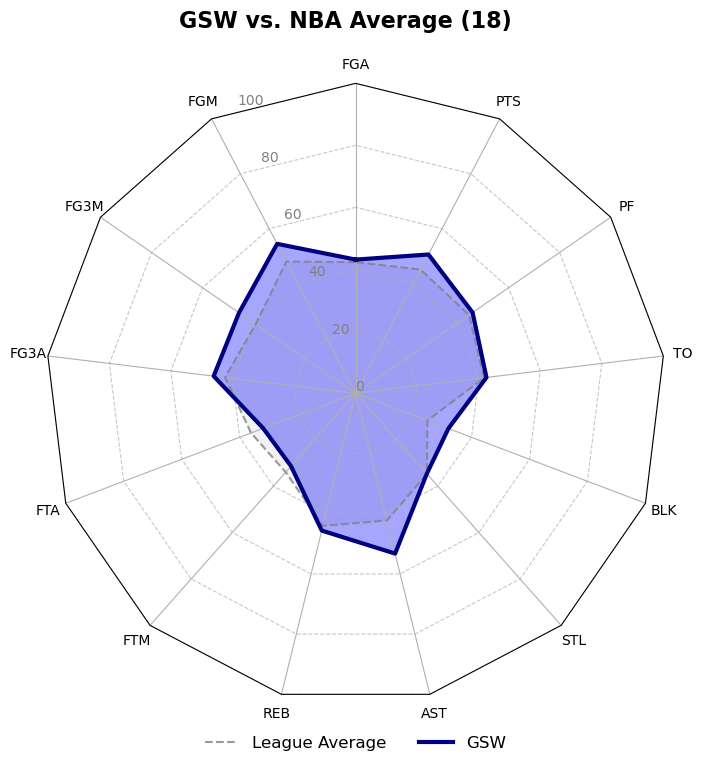

In [17]:
# Radar map: change the team and season
TEAM_TO_PLOT = 'GSW'
SEASON_TO_PLOT = 18
FRAME_TYPE = 'polygon'

# normalization across all data points to 0 - 100 scale
df_normalized = normalize_data(df, STATS_TO_COMPARE, min_val=0, max_val=100)

radar_data = get_normalized_radar_data(
    df_normalized=df_normalized, 
    team_name=TEAM_TO_PLOT, 
    season=SEASON_TO_PLOT, 
    stats_cols=STATS_TO_COMPARE
)

if radar_data:
    labels = radar_data['labels']
    team_values = radar_data['team_values']
    league_avg_values = radar_data['league_avg_values']
    
    # setup the radar chart parameters
    num_vars = len(labels)
    theta = radar_factory(num_vars, frame=FRAME_TYPE) 
    
    # define the range for the normalized data
    v_max = 100
    v_min = 0
    
    # define 6 grid lines (0, 20, 40, 60, 80, 100)
    grid_radii = np.linspace(v_min, v_max, 6) 

    # create the plot
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='radar'))
    for spine in ['left', 'right', 'top', 'bottom']:
        if spine in ax.spines:
            ax.spines[spine].set_visible(False)
    fig.subplots_adjust(top=0.95, bottom=0.05)
    ax.set_rgrids(grid_radii)
    ax.set_varlabels(labels)
    fig.suptitle(
        f"{TEAM_TO_PLOT} vs. NBA Average ({SEASON_TO_PLOT})", 
        fontsize=16, weight='bold', y=0.98  
    )
    fig.subplots_adjust(top=0.95, bottom=0.05)
        
    # plot league average (Grey)
    ax.plot(theta, league_avg_values, color='gray', linestyle='--', linewidth=1.5, alpha=0.8, label='League Average')
    ax.fill(theta, league_avg_values, facecolor='gray', alpha=0.1) 
    
    # plot team data (Blue)
    ax.plot(theta, team_values, color='navy', linewidth=3, label=TEAM_TO_PLOT)
    ax.fill(theta, team_values, facecolor='blue', alpha=0.35)
    
    ax.set_ylim(v_min, v_max) 
    rgrid_labels = [f'{int(r)}' for r in grid_radii]
    ax.set_yticklabels(rgrid_labels, fontsize=10, color='gray') 
    ax.tick_params(axis='y', pad=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7) 
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False, fontsize=12)
    plt.show()
else:
    print('Could not find the team')

# TOP 10 BEST PERFORMING TEAMS AND TOP 10 WORST PERFORMING TEAMS (SEASON 12 TO SEASON 24)
- FG3_PCT
- FT_PCT
- WIN_PCT
- EFG_PCT
- RESULT (MOST WINS/MOST LOSSES)

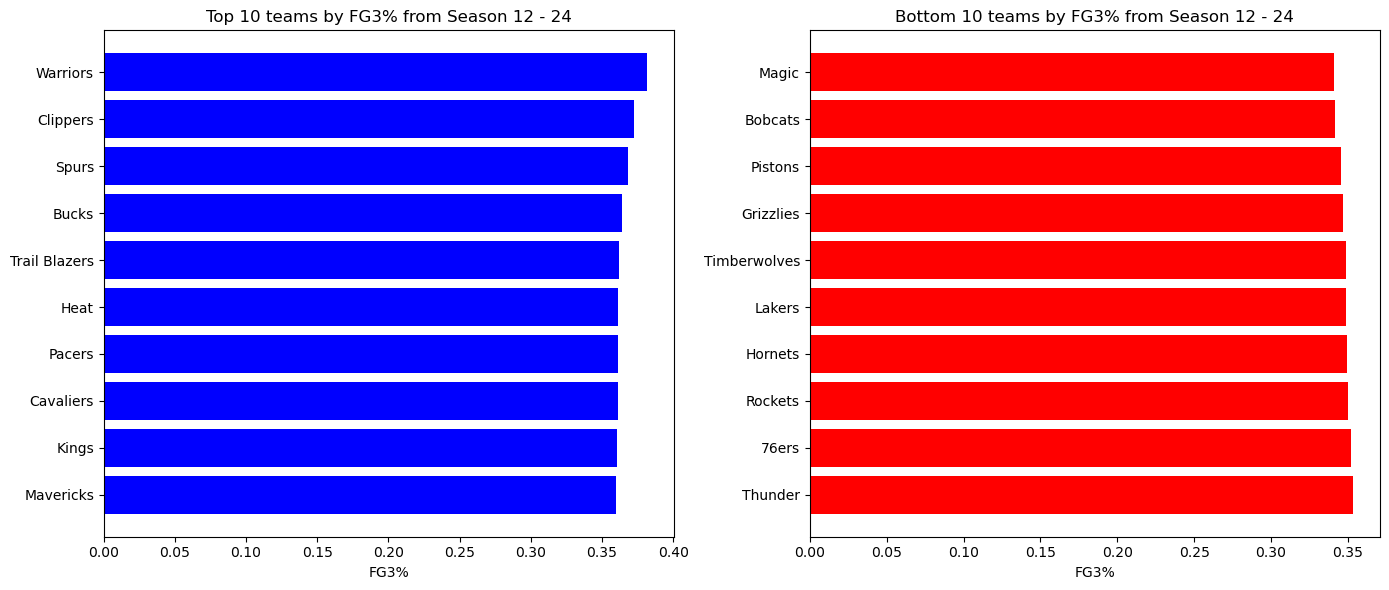

In [18]:
# top 10 best and 10 worst FG3_PCT
avg_fg3_pct = df.groupby('TEAM_NAME')['FG3_PCT'].mean().reset_index()
top_10_best_fg3 = avg_fg3_pct.sort_values('FG3_PCT', ascending= False).head(10) 
top_10_worst_fg3 = avg_fg3_pct.sort_values('FG3_PCT', ascending = True).head(10)

plt.figure(figsize =(14, 6))

plt.subplot(1, 2, 1)
plt.barh(top_10_best_fg3['TEAM_NAME'], top_10_best_fg3['FG3_PCT'], color = 'blue')
plt.title("Top 10 teams by FG3% from Season 12 - 24")
plt.xlabel('FG3%')
plt.gca().invert_yaxis()

plt.subplot(1,2,2)
plt.barh(top_10_worst_fg3['TEAM_NAME'], top_10_worst_fg3['FG3_PCT'], color = 'red')
plt.title("Bottom 10 teams by FG3% from Season 12 - 24")
plt.xlabel('FG3%')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

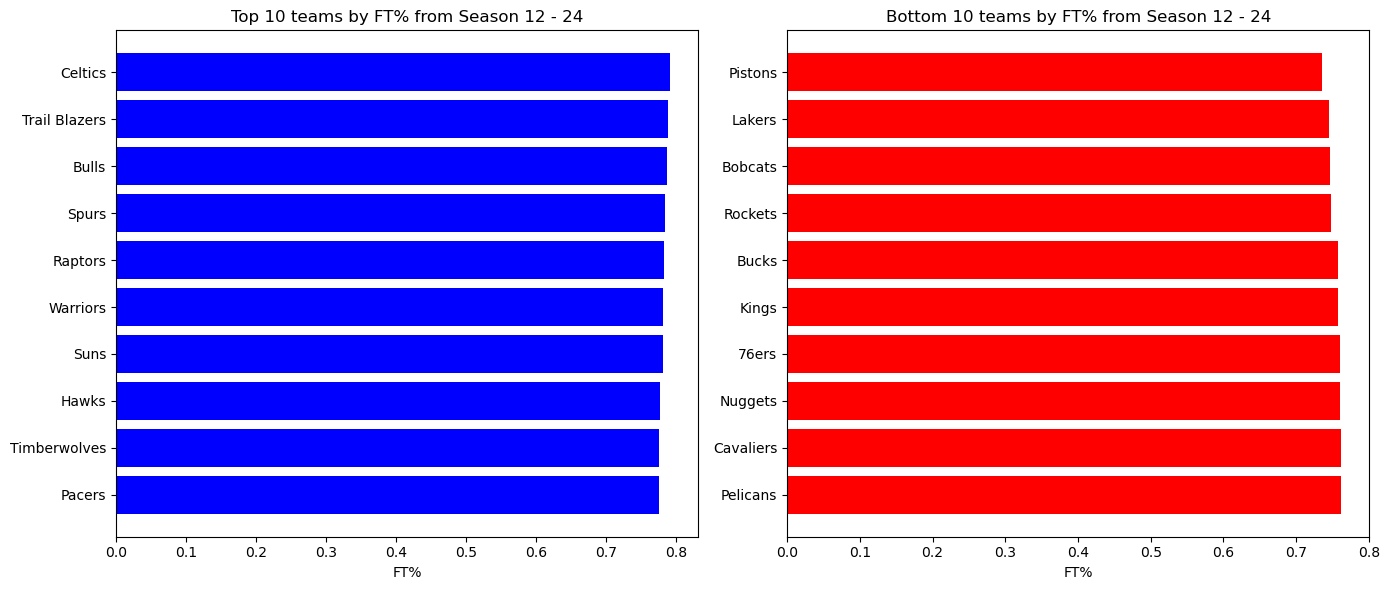

In [19]:
# top 10 best and 10 worst FT_PCT
avg_ft_pct = df.groupby('TEAM_NAME')['FT_PCT'].mean().reset_index()
top_10_best_ft = avg_ft_pct.sort_values('FT_PCT', ascending= False).head(10) 
top_10_worst_ft = avg_ft_pct.sort_values('FT_PCT', ascending = True).head(10)

plt.figure(figsize =(14, 6))

plt.subplot(1, 2, 1)
plt.barh(top_10_best_ft['TEAM_NAME'], top_10_best_ft['FT_PCT'], color ='blue')
plt.title("Top 10 teams by FT% from Season 12 - 24")
plt.xlabel('FT%')
plt.gca().invert_yaxis()

plt.subplot(1,2,2)
plt.barh(top_10_worst_ft['TEAM_NAME'], top_10_worst_ft['FT_PCT'], color ='red')
plt.title("Bottom 10 teams by FT% from Season 12 - 24")
plt.xlabel('FT%')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

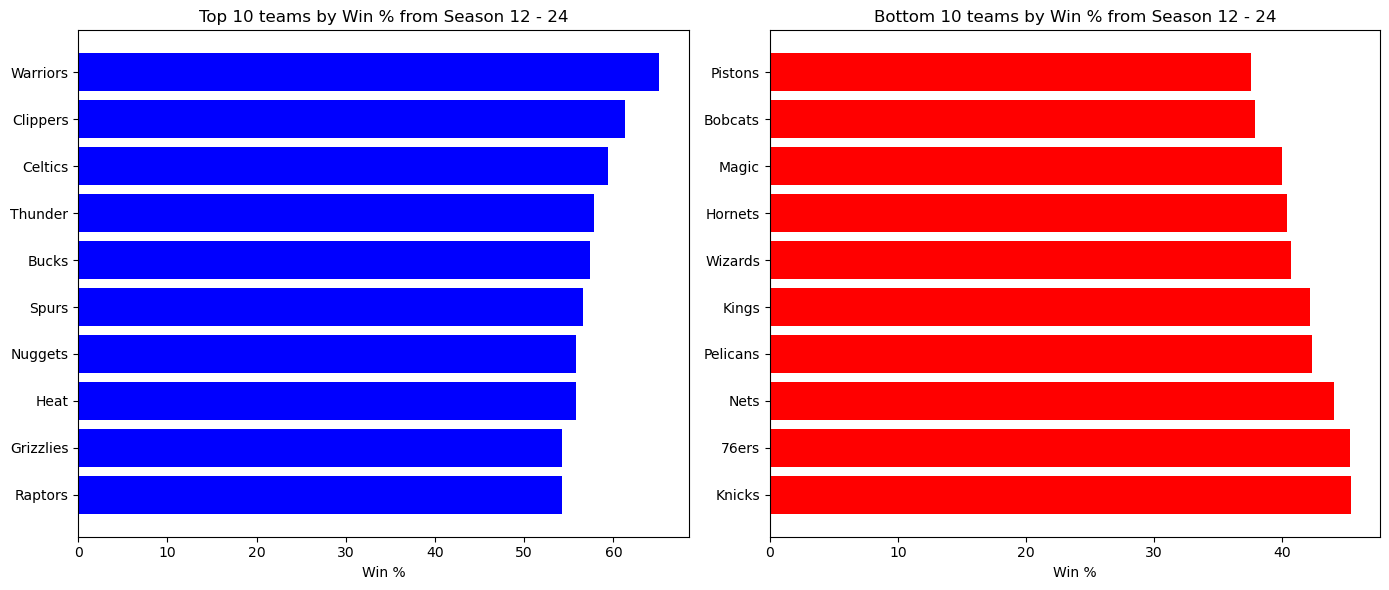

In [20]:
# top 10 best and 10 worst Win rate
avg_win_pct = df.groupby('TEAM_NAME')['WIN_PCT'].mean().reset_index()
top_10_best_win_pct = avg_win_pct.sort_values('WIN_PCT', ascending= False).head(10) 
top_10_worst_win_pct = avg_win_pct.sort_values('WIN_PCT', ascending = True).head(10)

plt.figure(figsize =(14, 6))

plt.subplot(1, 2, 1)
plt.barh(top_10_best_win_pct['TEAM_NAME'], top_10_best_win_pct['WIN_PCT'], color ='blue')
plt.title("Top 10 teams by Win % from Season 12 - 24")
plt.xlabel('Win %')
plt.gca().invert_yaxis()

plt.subplot(1,2,2)
plt.barh(top_10_worst_win_pct['TEAM_NAME'], top_10_worst_win_pct['WIN_PCT'], color ='red')
plt.title("Bottom 10 teams by Win % from Season 12 - 24")
plt.xlabel('Win %')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

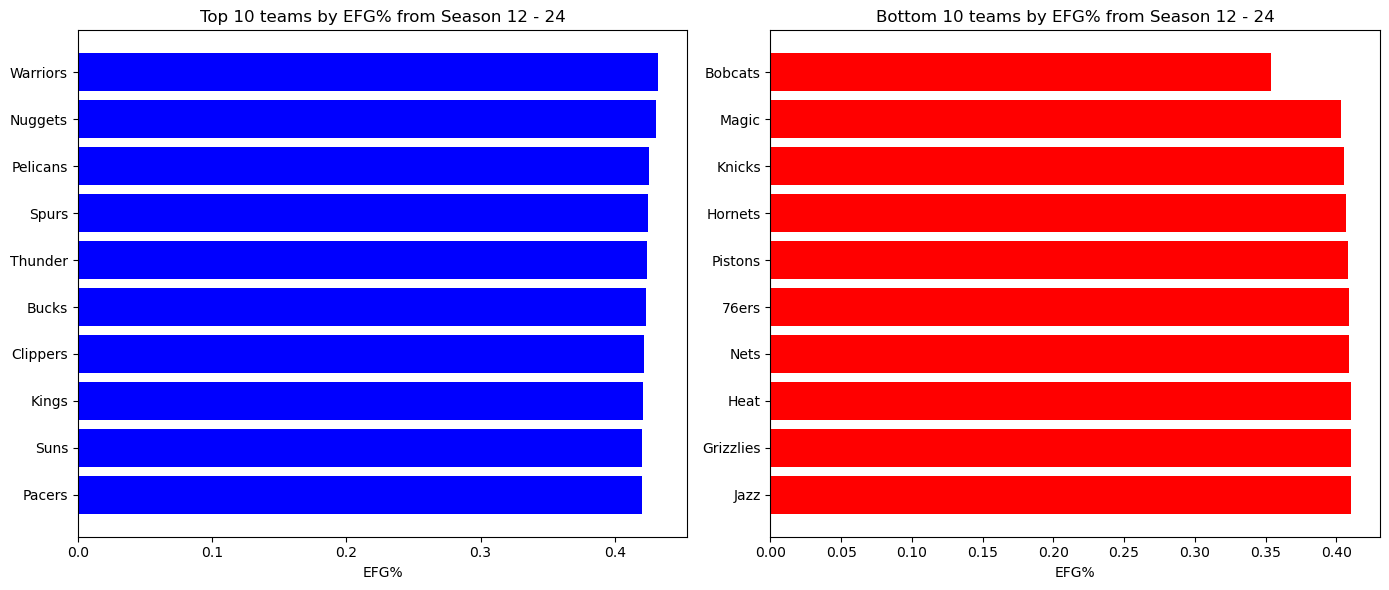

In [21]:
# top 10 best and 10 worst EFG_PCT
avg_efg_pct = df.groupby('TEAM_NAME')['EFG_PCT'].mean().reset_index()
top_10_best_efg = avg_efg_pct.sort_values('EFG_PCT', ascending= False).head(10) 
top_10_worst_efg = avg_efg_pct.sort_values('EFG_PCT', ascending = True).head(10)

plt.figure(figsize =(14, 6))

plt.subplot(1, 2, 1)
plt.barh(top_10_best_efg['TEAM_NAME'], top_10_best_efg['EFG_PCT'], color ='blue')
plt.title("Top 10 teams by EFG% from Season 12 - 24")
plt.xlabel('EFG%')
plt.gca().invert_yaxis()

plt.subplot(1,2,2)
plt.barh(top_10_worst_efg['TEAM_NAME'], top_10_worst_efg['EFG_PCT'], color ='red')
plt.title("Bottom 10 teams by EFG% from Season 12 - 24")
plt.xlabel('EFG%')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

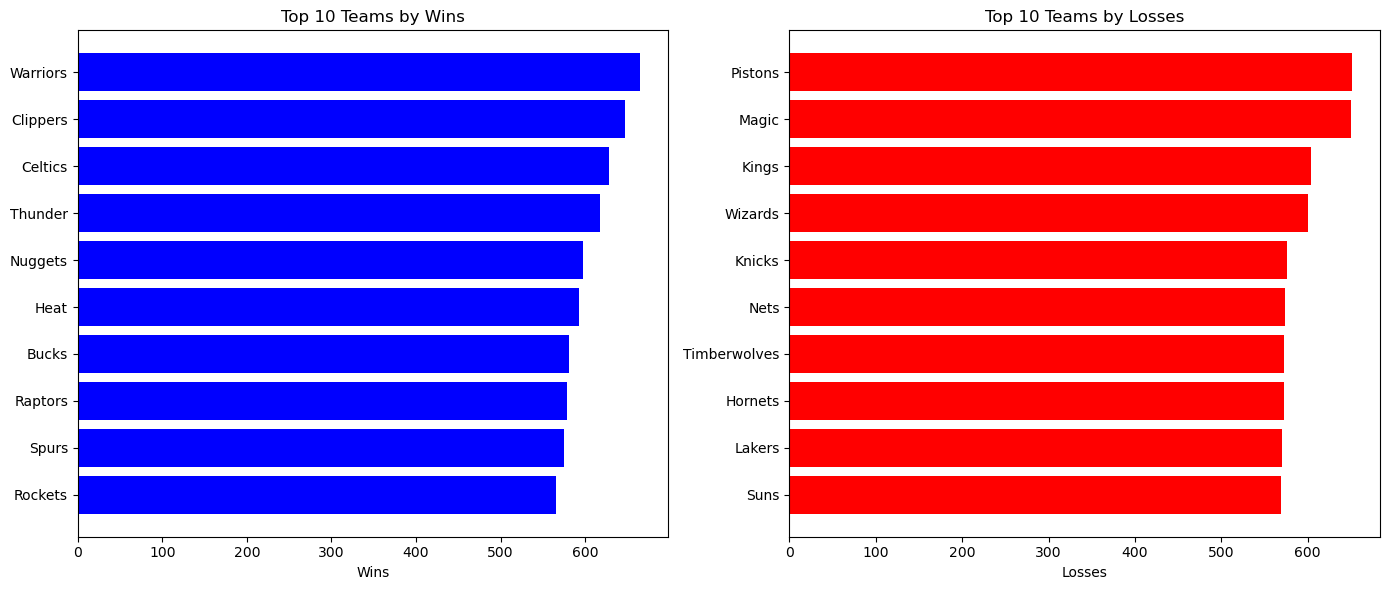

In [22]:
# top 10 teams with most wins/losses
team_results = df.groupby('TEAM_NAME')['RESULT'].value_counts().unstack(fill_value=0)
team_results.rename(columns={1: 'WINS', 0: 'LOSSES'}, inplace=True)
team_results = team_results.reset_index()

top10_wins = team_results.sort_values('WINS', ascending=False).head(10)
top10_losses = team_results.sort_values('LOSSES', ascending=False).head(10)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.barh(
    top10_wins['TEAM_NAME'],
    top10_wins['WINS'],
    color='blue'
)
plt.title("Top 10 Teams by Wins")
plt.xlabel("Wins")
plt.gca().invert_yaxis()

plt.subplot(1, 2, 2)
plt.barh(
    top10_losses['TEAM_NAME'],
    top10_losses['LOSSES'],
    color='red'
)
plt.title("Top 10 Teams by Losses")
plt.xlabel("Losses")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# SECTION 3: CORRELATION ANALYSIS

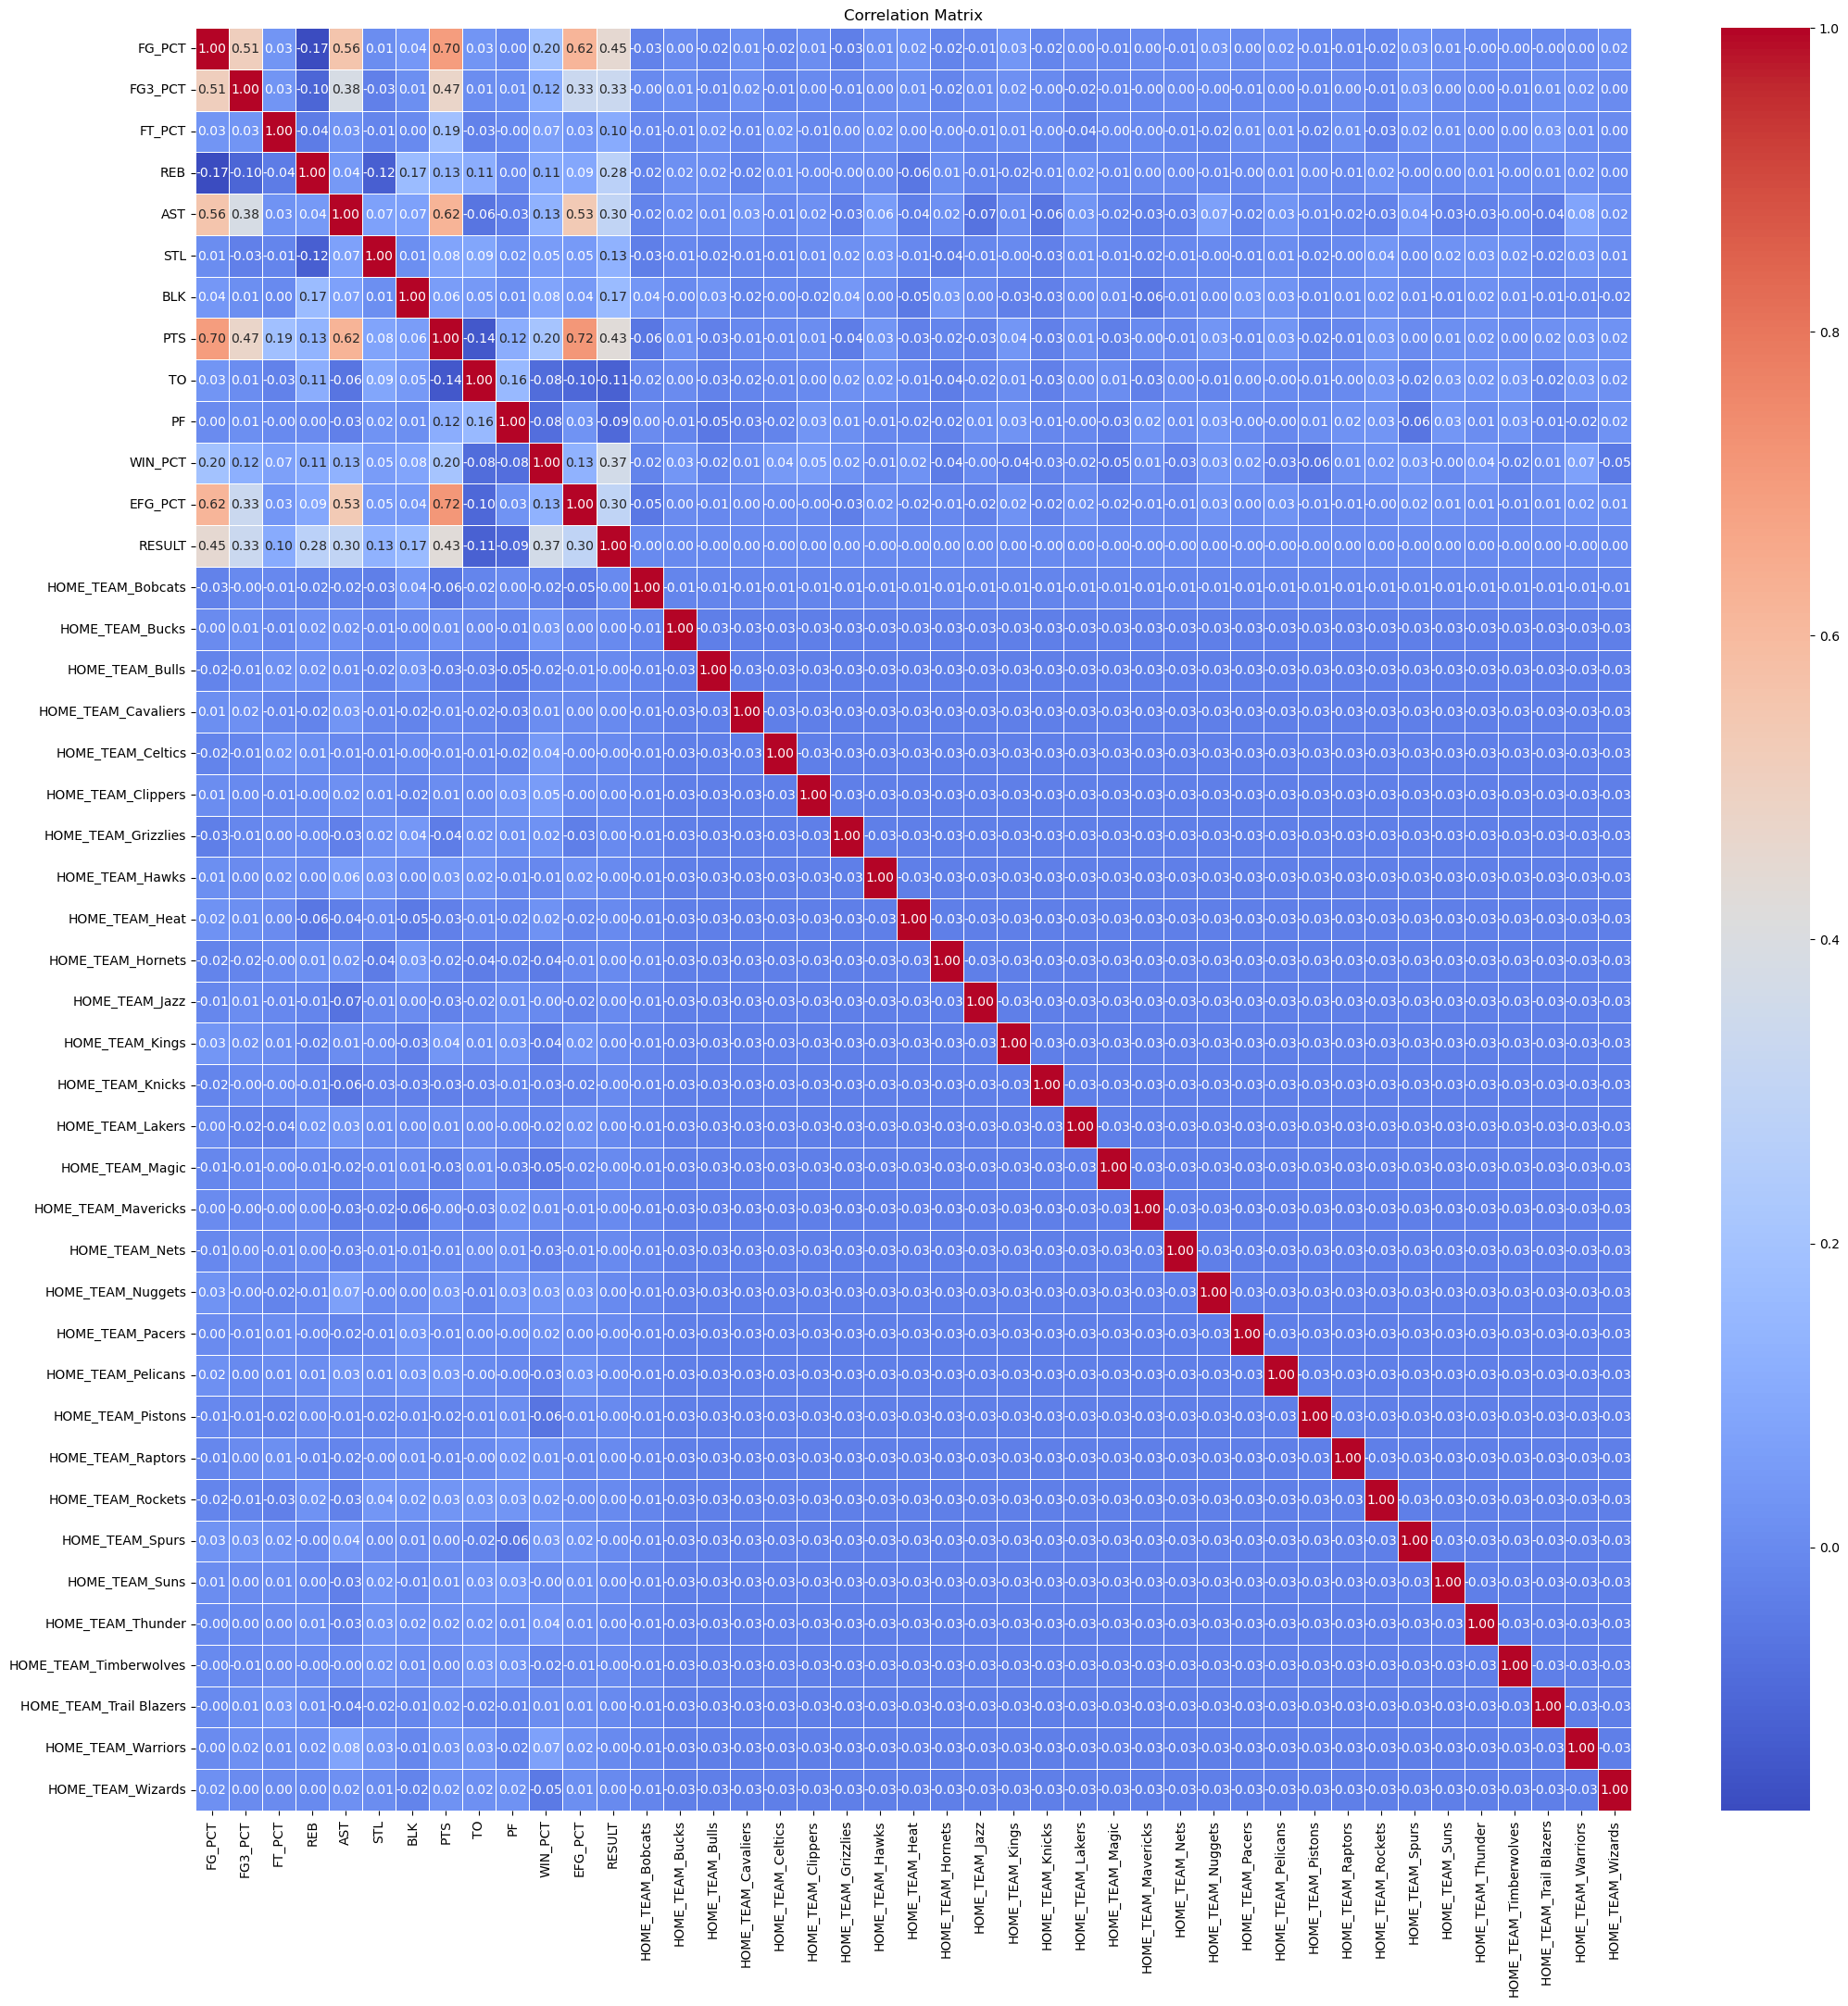

In [23]:
# select columns for correlation
cols_for_correl = [
    'FG_PCT', 'FG3_PCT', 'FT_PCT', 'REB',
    'AST', 'STL', 'BLK', 'PTS', 'TO', 'PF',
    'WIN_PCT', 'EFG_PCT', 'RESULT', 'HOME_TEAM'
]
df_subset = df[cols_for_correl].copy()

df_final = pd.get_dummies(df_subset, columns = ['HOME_TEAM'], drop_first= True)
correl_matrix = df_final.corr()

# plot the heatmap
plt.figure(figsize= (25, 25))
sns.heatmap(correl_matrix, annot = True, fmt = '.2f', cmap = 'coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

# SECTION 4: TEST STATISTICS

# Hypothesis 1
H0: There is **no significant** home-court advantage. <br>
H1: There is a **significant** home-court advantage.

In [24]:
# set alpha = 0.05
alpha = 0.05
# since we have more than 30 samples, it is best to use z-test
df['IS_HOME_TEAM'] = (df['TEAM_NAME'] == df['HOME_TEAM']).astype('Int64')

# seperate home and away
df_home = df[df['IS_HOME_TEAM'] == 1]
x_home = df_home['RESULT'].sum()
n_home = len(df_home)

df_away = df[df['IS_HOME_TEAM'] == 0]
x_away = df_away['RESULT'].sum()
n_away = len(df_away)

# use one-tailed z-test to see if Phome > Paway or not
counts = [x_home, x_away]
nobs = [n_home, n_away]
z_stat, p_value = proportions_ztest(counts, nobs, alternative='larger')
print(f"Z-Statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.10f}")
if p_value < alpha:
    print(f"Conclusion: Reject H0 since P-value ({p_value:.10f}) < {alpha}.")
    print('Reject the null hypothesis. There is a significant home-court advantage.')
else:
    print('Fail to reject the null hypothesis. No significant evidence of home-court advantage.')

Z-Statistic: 25.1594
P-value: 0.0000000000
Conclusion: Reject H0 since P-value (0.0000000000) < 0.05.
Reject the null hypothesis. There is a significant home-court advantage.


# Hypothesis 2
H0: The average total point of winners is **different** than the average total point of losers.
H1: The average total point of winners is **not different** than the average total point of losers

In [25]:
# seperate the points of winner (RESULT == 1) and points of lossers (RESULT == 0)
pts_win = df[df['RESULT'] == 1]['PTS']
pts_loss = df[df['RESULT'] == 0]['PTS']

# calculate mean and the total wins and losses
mean_win = pts_win.mean()
mean_loss = pts_loss.mean()
n_win = len(pts_win)
n_loss = len(pts_loss)

# use 2-sample t-test (Welch's test)
t_stat, p_value = stats.ttest_ind(pts_win, pts_loss, equal_var=False, alternative= 'greater')

# print result
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.10f}")
if p_value < alpha:
    print(f"Conclusion: Reject H0 since P-value ({p_value:.10f}) < {alpha}.")
    print(f"The mean points scored by winning teams ({mean_win : .2f}) is significantly greater than the mean points scored by losing teams ({mean_loss : .2f}).")
else:
    print(f"Conclusion: Fail to Reject H0 since P-value ({p_value:.10f}) >= Alpha ({alpha}).")
    print("The difference in mean points is not statistically significant.")

T-Statistic: 84.4188
P-value: 0.0000000000
Conclusion: Reject H0 since P-value (0.0000000000) < 0.05.
The mean points scored by winning teams ( 113.58) is significantly greater than the mean points scored by losing teams ( 101.98).


# SECTION 5: SIMPLE AND MULTIVARIATE REGRESSIONS 

# Simple regressions for: 
- FG_PCT vs. FG3_PCT <br>
- FG_PCT vs. AST <br>
- FG_PCT vs. PTS <br>
- AST vs PST <br>
- EFG_PCT vs. PST <br>
- EFG_PCT vs. AST 

# Simple regression 1 with X = FG_PCT and Y = FG3_PCT
Result: <br>
- Statistically significant relationship with p-value < 0.05. <br>
- Slope = 0.8617 -> for 1% increase in FG_PCT, FG3_PCT increases by 0.8617%. <br>
- R-squared = 0.263 -> FG_PCT explains 26.3% of variations in FG3_PCT.Weak relationship. <br>
- Formula: FG3_PCT = 0.8617 * FG_PCT - 0.0407 <br>
***CONCLUSION***: <br>
- Weak but positive and statistically significant relationship. However, with low r-squared, other factors may explain changes in FG3_PCT better such as FG3M and FG3A.

In [26]:
ols1 = df[['FG_PCT', 'FG3_PCT']]
form1 = 'FG3_PCT ~ FG_PCT'
OLS_1 = ols(formula = form1, data = ols1)
model_l = OLS_1.fit()
model_l.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                FG3_PCT   R-squared:                       0.263
Model:                            OLS   Adj. R-squared:                  0.263
Method:                 Least Squares   F-statistic:                 1.117e+04
Date:                Fri, 06 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:18:36   Log-Likelihood:                 34744.
No. Observations:               31340   AIC:                        -6.948e+04
Df Residuals:                   31338   BIC:                        -6.947e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0407      0.004    -10.731      0.000      -0.048      -0.033
FG_PCT         0.8617      0.008    105.671      0.000       0.846       0.878
==============================================================================
Omnibus:                      306.824   Durbin-Watson:                   2.010
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              516.907
Skew:                           0.013   Prob(JB):                    5.69e-113
Kurtosis:                       3.629   Cond. No.                         21.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

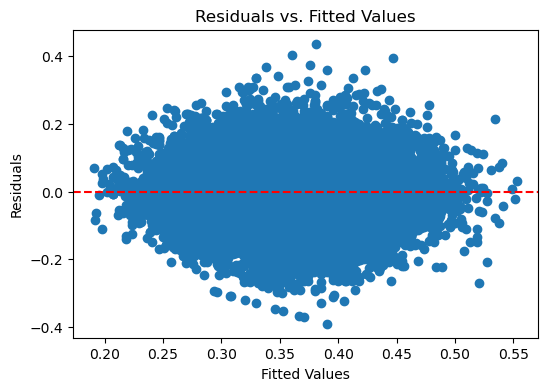

In [27]:
# residual vs fitted values plot to check for homoscedasticity
# no clear pattern with values being randomly scattered
resid_1 = model_l.resid
fit_vals = model_l.fittedvalues
plt.figure(figsize=(6, 4))
plt.scatter(fit_vals, resid_1)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

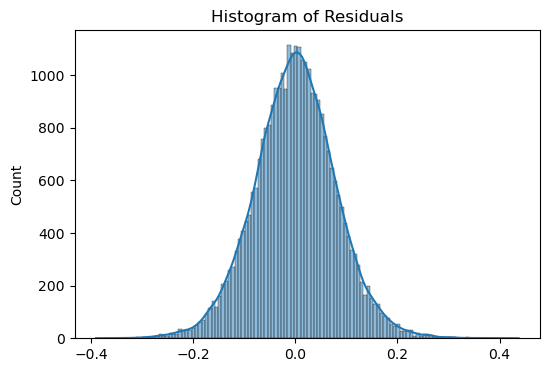

In [28]:
# Histogram of Residuals (Check for Normality)
# The histogram shows normal distribution, no heavy tail
plt.figure(figsize=(6, 4))
sns.histplot(resid_1, kde=True)
plt.title('Histogram of Residuals')
plt.show()

# Simple regression 2 with X = FG_PCT and Y = AST
Result: <br>
- Statistically significant relationship with p-value < 0.05. <br>
- Slope = 53.4016 -> every 1% increase in FG_PCT, AST increase by 53.4016 points. <br>
- Formula: AST = 53.4016 * FG_PCT - 0.7292 <br>
- R-squared = 0.310. FG_PCT explains 31% of variations in AST. Weak relationship. <br> 
***CONCLUSION***:
- Weak but positive and statistically significant relationship. However, other factors, such as PTS, REB, TO, may explain changes in AST better.

In [29]:
ols2 = df[['FG_PCT', 'AST']]
form2 = 'AST ~ FG_PCT'
OLS_2 = ols(formula = form2, data = ols2)
model_2 = OLS_2.fit()
model_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    AST   R-squared:                       0.310
Model:                            OLS   Adj. R-squared:                  0.310
Method:                 Least Squares   F-statistic:                 1.408e+04
Date:                Fri, 06 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:18:39   Log-Likelihood:                -90948.
No. Observations:               31340   AIC:                         1.819e+05
Df Residuals:                   31338   BIC:                         1.819e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.7292      0.209     -3.484      0.000      -1.139      -0.319
FG_PCT        53.4016      0.450    118.679      0.000      52.520      54.284
==============================================================================
Omnibus:                        6.899   Durbin-Watson:                   1.725
Prob(Omnibus):                  0.032   Jarque-Bera (JB):                6.912
Skew:                           0.031   Prob(JB):                       0.0316
Kurtosis:                       3.038   Cond. No.                         21.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

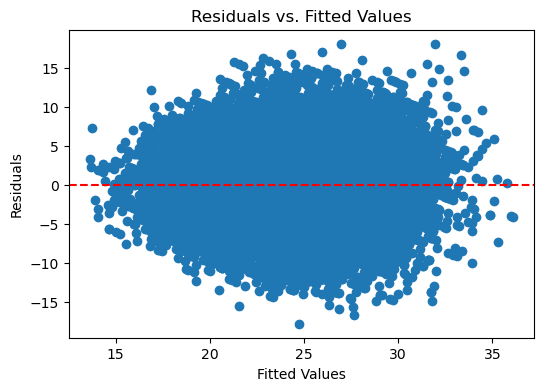

In [30]:
# residual vs fitted values plot to check for homoscedasticity
# no clear pattern with values being randomly scattered
resid_2 = model_2.resid
fit_vals_2 = model_2.fittedvalues
plt.figure(figsize=(6, 4))
plt.scatter(fit_vals_2, resid_2)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

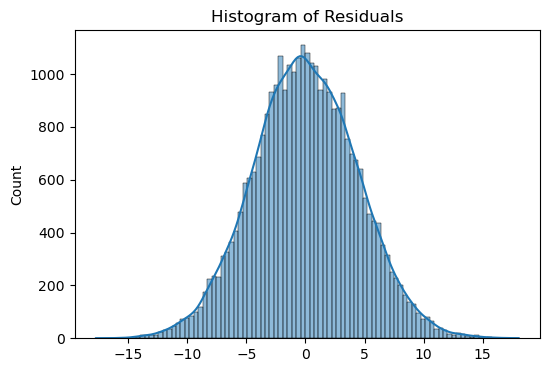

In [31]:
# Histogram of Residuals (Check for Normality)
# The histogram shows normal distribution, no heavy tail
plt.figure(figsize=(6, 4))
sns.histplot(resid_2, kde=True)
plt.title('Histogram of Residuals')
plt.show()

# Simple regression 3 with X = FG_PCT and Y = PTS
Result: <br>
- Statistically significant relationship with p-value < 0.05. <br>
- Slope = 169.3964 -> every 1% increase in FG_PCT, PTS increase by 169.3964 points. <br>
- Formula: PTS = 169.3964 * FG_PCT + 29.5482 <br>
- R-squared = 0.484. FG_PCT explains 48.4% of variations in PST. Weak relationship. <br> 
***CONCLUSION***:
- Weak but positive and statistically significant relationship. However, other factors, such as PTS, AST, TO, may explain changes in PTS better.

In [32]:
ols3 = df[['FG_PCT', 'PTS']]
form3 = 'PTS ~ FG_PCT'
OLS_3 = ols(formula = form3, data = ols3)
model_3 = OLS_3.fit()
model_3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    PTS   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.484
Method:                 Least Squares   F-statistic:                 2.938e+04
Date:                Fri, 06 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:18:40   Log-Likelihood:            -1.1560e+05
No. Observations:               31340   AIC:                         2.312e+05
Df Residuals:                   31338   BIC:                         2.312e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     29.5482      0.460     64.288      0.000      28.647      30.449
FG_PCT       169.3964      0.988    171.420      0.000     167.459     171.333
==============================================================================
Omnibus:                      237.204   Durbin-Watson:                   1.220
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              253.503
Skew:                           0.187   Prob(JB):                     8.96e-56
Kurtosis:                       3.232   Cond. No.                         21.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

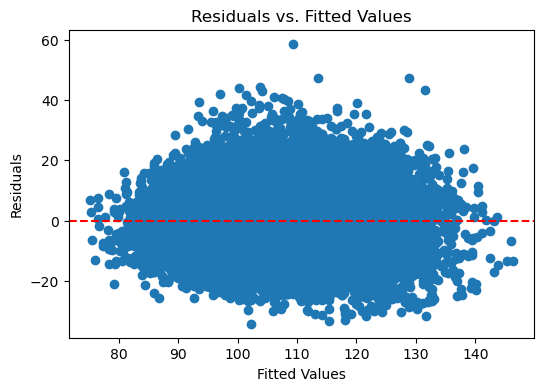

In [33]:
# residual vs fitted values plot to check for homoscedasticity
# no clear pattern with values being randomly scattered
resid_3 = model_3.resid
fit_vals_3 = model_3.fittedvalues
plt.figure(figsize=(6, 4))
plt.scatter(fit_vals_3, resid_3)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

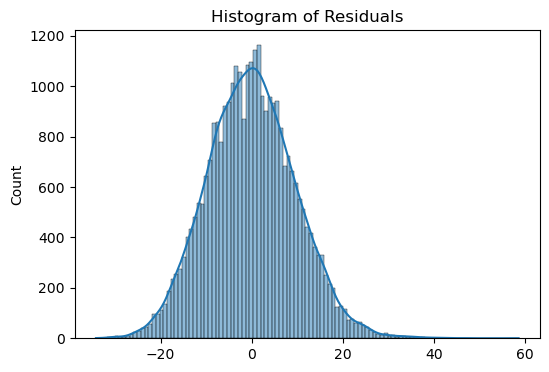

In [34]:
# Histogram of Residuals (Check for Normality)
# The histogram shows normal distribution, no heavy tail
plt.figure(figsize=(6, 4))
sns.histplot(resid_3, kde=True)
plt.title('Histogram of Residuals')
plt.show()

# Simple regression 4 with X = AST and Y = PTS
Result: <br>
- Statistically significant relationship with p-value < 0.05. <br>
- Slope = 1.5765 -> every 1 unit increase in AST, PTS increase by 1.5765 units. <br>
- Formula: PTS = 1.5765 * AST + 70.0484 <br>
- R-squared = 0.385. FG_PCT explains 38.5% of variations in PST. Weak relationship. <br> 
***CONCLUSION***:
- Weak but positive and statistically significant relationship. However, other factors, such as REB, STL, TO, may explain changes in PTS better.

In [35]:
ols4 = df[['AST', 'PTS']]
form4 = 'PTS ~ AST'
OLS_4 = ols(formula = form4, data = ols4)
model_4 = OLS_4.fit()
model_4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    PTS   R-squared:                       0.385
Model:                            OLS   Adj. R-squared:                  0.385
Method:                 Least Squares   F-statistic:                 1.966e+04
Date:                Fri, 06 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:18:42   Log-Likelihood:            -1.1834e+05
No. Observations:               31340   AIC:                         2.367e+05
Df Residuals:                   31338   BIC:                         2.367e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     70.0484      0.276    254.131      0.000      69.508      70.589
AST            1.5765      0.011    140.202      0.000       1.554       1.599
==============================================================================
Omnibus:                      151.762   Durbin-Watson:                   1.504
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              153.978
Skew:                           0.169   Prob(JB):                     3.66e-34
Kurtosis:                       3.063   Cond. No.                         113.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

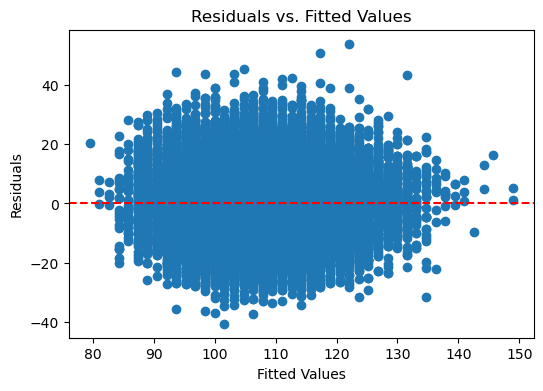

In [36]:
# residual vs fitted values plot to check for homoscedasticity
# no clear pattern with values being randomly scattered
resid_4 = model_4.resid
fit_vals_4 = model_4.fittedvalues
plt.figure(figsize=(6, 4))
plt.scatter(fit_vals_4, resid_4)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

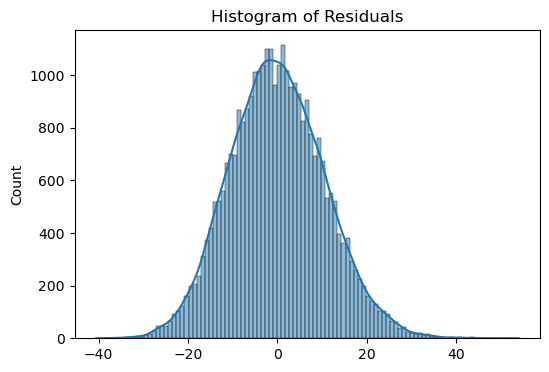

In [37]:
# Histogram of Residuals (Check for Normality)
# The histogram shows normal distribution, no heavy tail
plt.figure(figsize=(6, 4))
sns.histplot(resid_4, kde=True)
plt.title('Histogram of Residuals')
plt.show()

# Simple regression 5 with X = EFG_PCT and Y = AST
Result: <br>
- Statistically significant relationship with p-value < 0.05. <br>
- Slope = 38.8127 -> every 1% increase in EFG_PCT, AST increase by 38.8127 points. <br>
- Formula: AST = 38.8127 * EFG_PCT + 7.7917 <br>
- R-squared = 0.285. FG_PCT explains 28.5% of variations in PST. Weak relationship. <br> 
***CONCLUSION***:
- Weak but positive and statistically significant relationship. However, other factors, such as REB, STL, TO, may explain changes in AST better.

In [38]:
ols5 = df[['EFG_PCT', 'AST']]
form5 = 'AST ~ EFG_PCT'
OLS_5 = ols(formula = form5, data = ols5)
model_5 = OLS_5.fit()
model_5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    AST   R-squared:                       0.285
Model:                            OLS   Adj. R-squared:                  0.285
Method:                 Least Squares   F-statistic:                 1.250e+04
Date:                Fri, 06 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:18:43   Log-Likelihood:                -91503.
No. Observations:               31340   AIC:                         1.830e+05
Df Residuals:                   31338   BIC:                         1.830e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.7917      0.147     53.168      0.000       7.504       8.079
EFG_PCT       38.8127      0.347    111.824      0.000      38.132      39.493
==============================================================================
Omnibus:                        2.618   Durbin-Watson:                   1.607
Prob(Omnibus):                  0.270   Jarque-Bera (JB):                2.647
Skew:                           0.008   Prob(JB):                        0.266
Kurtosis:                       3.042   Cond. No.                         16.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

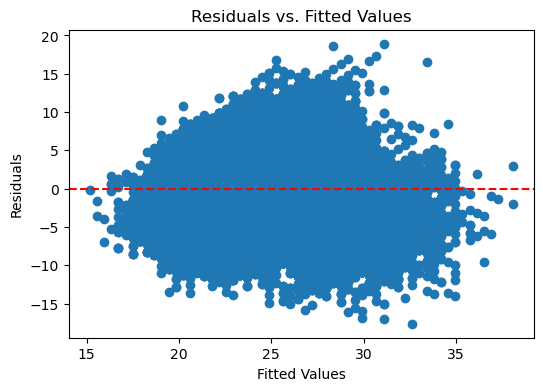

In [39]:
# residual vs fitted values plot to check for homoscedasticity
# no clear pattern with values being randomly scattered
resid_5 = model_5.resid
fit_vals_5 = model_5.fittedvalues
plt.figure(figsize=(6, 4))
plt.scatter(fit_vals_5, resid_5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

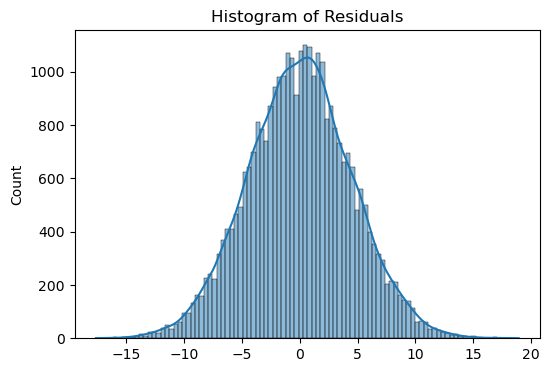

In [40]:
# Histogram of Residuals (Check for Normality)
# The histogram shows normal distribution, no heavy tail
plt.figure(figsize=(6, 4))
sns.histplot(resid_5, kde=True)
plt.title('Histogram of Residuals')
plt.show()

# Simple regression 6 with X = EFG_PCT and Y = PTS
Result: <br>
- Statistically significant relationship with p-value < 0.05. <br>
- Slope = 132.0548 -> every 1% increase in EFG_PCT, PTS increase by 132.0548 points. <br>
- Formula: PTS = 132.0548 * EFG_PCT + 52.8612 <br>
- R-squared = 0.512. FG_PCT explains 51.2% of variations in PST. Moderate relationship. <br> 
***CONCLUSION***:
- Moderate, positive and statistically significant relationship.

In [41]:
ols6 = df[['EFG_PCT', 'PTS']]
form6 = 'PTS ~ EFG_PCT'
OLS_6 = ols(formula = form6, data = ols6)
model_6 = OLS_6.fit()
model_6.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    PTS   R-squared:                       0.512
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                 3.289e+04
Date:                Fri, 06 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:18:44   Log-Likelihood:            -1.1472e+05
No. Observations:               31340   AIC:                         2.295e+05
Df Residuals:                   31338   BIC:                         2.295e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     52.8612      0.307    171.936      0.000      52.259      53.464
EFG_PCT      132.0548      0.728    181.353      0.000     130.628     133.482
==============================================================================
Omnibus:                       90.185   Durbin-Watson:                   1.077
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               91.643
Skew:                          -0.124   Prob(JB):                     1.26e-20
Kurtosis:                       3.095   Cond. No.                         16.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

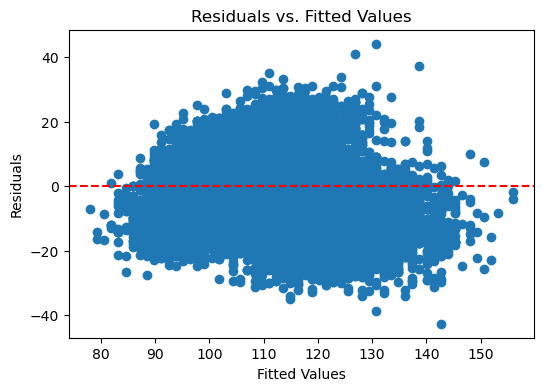

In [42]:
# residual vs fitted values plot to check for homoscedasticity
# no clear pattern with values being randomly scattered
resid_6 = model_6.resid
fit_vals_6 = model_6.fittedvalues
plt.figure(figsize=(6, 4))
plt.scatter(fit_vals_6, resid_6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

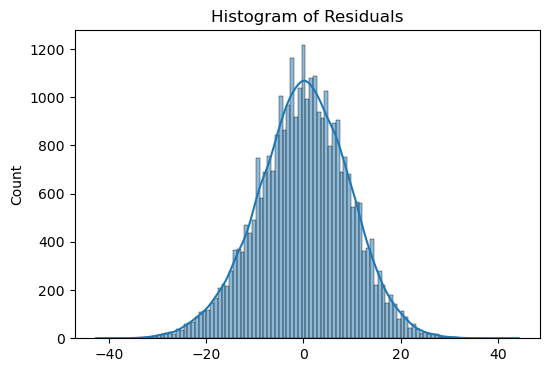

In [43]:
# Histogram of Residuals (Check for Normality)
# The histogram shows normal distribution, no heavy tail
plt.figure(figsize=(6, 4))
sns.histplot(resid_6, kde=True)
plt.title('Histogram of Residuals')
plt.show()

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31340 entries, 0 to 31339
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GAME_ID            31340 non-null  object 
 1   TEAM_ID            31340 non-null  object 
 2   TEAM_NAME          31340 non-null  object 
 3   TEAM_ABBREVIATION  31340 non-null  object 
 4   TEAM_CITY          31340 non-null  object 
 5   HOME_TEAM          31340 non-null  object 
 6   MIN                31340 non-null  int64  
 7   FGM                31340 non-null  int64  
 8   FGA                31340 non-null  int64  
 9   FG_PCT             31340 non-null  float64
 10  FG3M               31340 non-null  int64  
 11  FG3A               31340 non-null  int64  
 12  FG3_PCT            31340 non-null  float64
 13  FTM                31340 non-null  int64  
 14  FTA                31340 non-null  int64  
 15  FT_PCT             31340 non-null  float64
 16  OREB               313

# MULTIVARIATE REGRESSION WITH Y VARIABLE = RESULT AND X VARIABLES = OTHER INT COLS

Result: <br>
- Overall, the model is statistically significant with p-value < 0.05. <br>
- While most independent variables are statistically significant, some are not statistically significant. These includes BLK_YJ, STL_YJ, FT_PCT_YJ
- R-squared = 0.512. FG_PCT explains 51.2% of variations in PST. Moderate relationship. <br> 
***CONCLUSION***:
- Moderate, positive and statistically significant relationship.

In [50]:
# multivariate regression
cols_to_multi = [
    'FGA', 'FG_PCT', 'FG3A', 'FG3_PCT', 'FTA', 'FT_PCT', 
    'OREB', 'DREB', 'AST', 'STL', 'BLK', 'TO', 'PF'
]

cols_to_multi_trans = [
    'FGA', 'FG_PCT', 'FG3A', 'FG3_PCT', 'FTA', 'FT_PCT', 'OREB', 
    'DREB', 'AST', 'STL', 'BLK', 'TO', 'PF', 'FTA_YJ', 
    'OREB_YJ', 'STL_YJ', 'BLK_YJ', 'EFG_PCT_YJ', 'FT_PCT_YJ'
]

# scale x variables to reduce VIF
scaler = StandardScaler()
x_multi = df_transformed[cols_to_multi_trans]
x_scaled = pd.DataFrame(scaler.fit_transform(x_multi), columns = x_multi.columns)

y_target = df_transformed['RESULT']
x_with_const = sm.add_constant(x_scaled)
multi_model = sm.OLS(y_target, x_with_const).fit()

# VIF
vif_df = pd.DataFrame()
vif_df["Feature"] = x_scaled.columns
vif_df["VIF"] = [variance_inflation_factor(x_scaled.values, i) for i in range(x_scaled.shape[1])]

print('Multivariate Regression Summary')
print(multi_model.summary())
print("\nVariance Inflation Factor (VIF)")
print(vif_df.sort_values(by="VIF", ascending=False))

Multivariate Regression Summary
                            OLS Regression Results                            
Dep. Variable:                 RESULT   R-squared:                       0.501
Model:                            OLS   Adj. R-squared:                  0.501
Method:                 Least Squares   F-statistic:                     1657.
Date:                Fri, 06 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:55:25   Log-Likelihood:                -11844.
No. Observations:               31340   AIC:                         2.373e+04
Df Residuals:                   31320   BIC:                         2.389e+04
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.500

# SECTION 6: MACHINE LEARNING - PREDICTING RESULTS <br>
Use: <br>
- XGBoost <br>
- Random Forest <br>
- Stratified CV Fold <br>
Goal: predict result (1 or 0) for each team in the 2025 season

In [46]:
# create a copy of the dataset (original)
df_cleaned = df.copy()

# use the cols_to_multi
X = df_cleaned[cols_to_multi]
y = df_cleaned['RESULT']

# train test split with train = 80% and test = 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# random forest
rf_model = RandomForestClassifier(n_estimators= 100, random_state = 42, n_jobs = -1)

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='logloss',
    random_state=42
)

# 5-fold Stratified cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

results = {}
for name, model in models.items():
    # use X_train and y_train 
    cv_results = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
    results[name] = cv_results
    print(f"{name} CV Mean Accuracy: {cv_results.mean():.4f}")

Random Forest CV Mean Accuracy: 0.8173
XGBoost CV Mean Accuracy: 0.8336


In [ ]:
# since XGBoost has higher accuracy, we are going use this model to predict on X_test
best_model = xgb_model
xgb_model.fit(X_train, y_train) # fit xgb model
rf_model.fit(X_train, y_train) # fit random forest model
y_pred = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.84      0.84      3134
           1       0.84      0.83      0.83      3134

    accuracy                           0.83      6268
   macro avg       0.83      0.83      0.83      6268
weighted avg       0.83      0.83      0.83      6268



### CONFUSION MATRIX INTERPRETATION <br>
Result: <br>
- True Negative (TN) = 2643 -> Correctly predicted losses <br>
- False Positive (FP) = 491 -> Predicted wins, but actually losses <br>
- False Negative (FN) = 544 -> Predicted losses, but actually wins <br>
- True Positive (TP) = 2590 -> Correctly predicted wins <br>
Combined with the classification report above, this shows that the best performing model (XGBoost) performs well in predicting match outcomes with an overall accuracy of 83%. The model correctly classifies both wins and losses at similar rates, indicating no significant class bias. While some misclassifications remain, the balance between false positives and false negatives suggests a stable and reliable prediction model. 

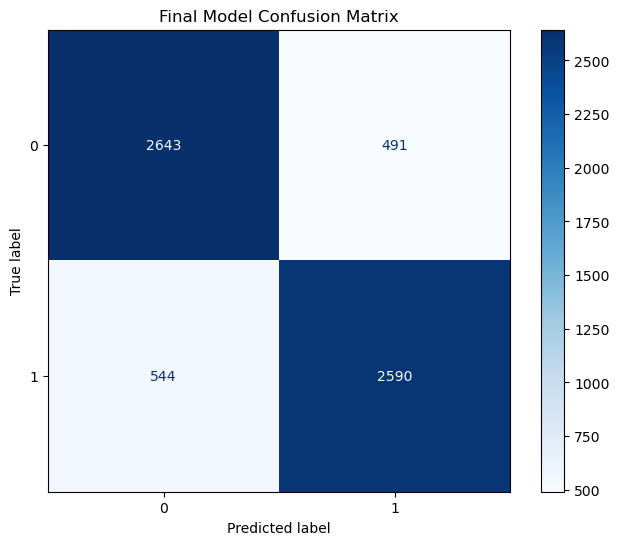

In [57]:
# confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap='Blues', ax=ax)
plt.title('Final Model Confusion Matrix')
plt.show()

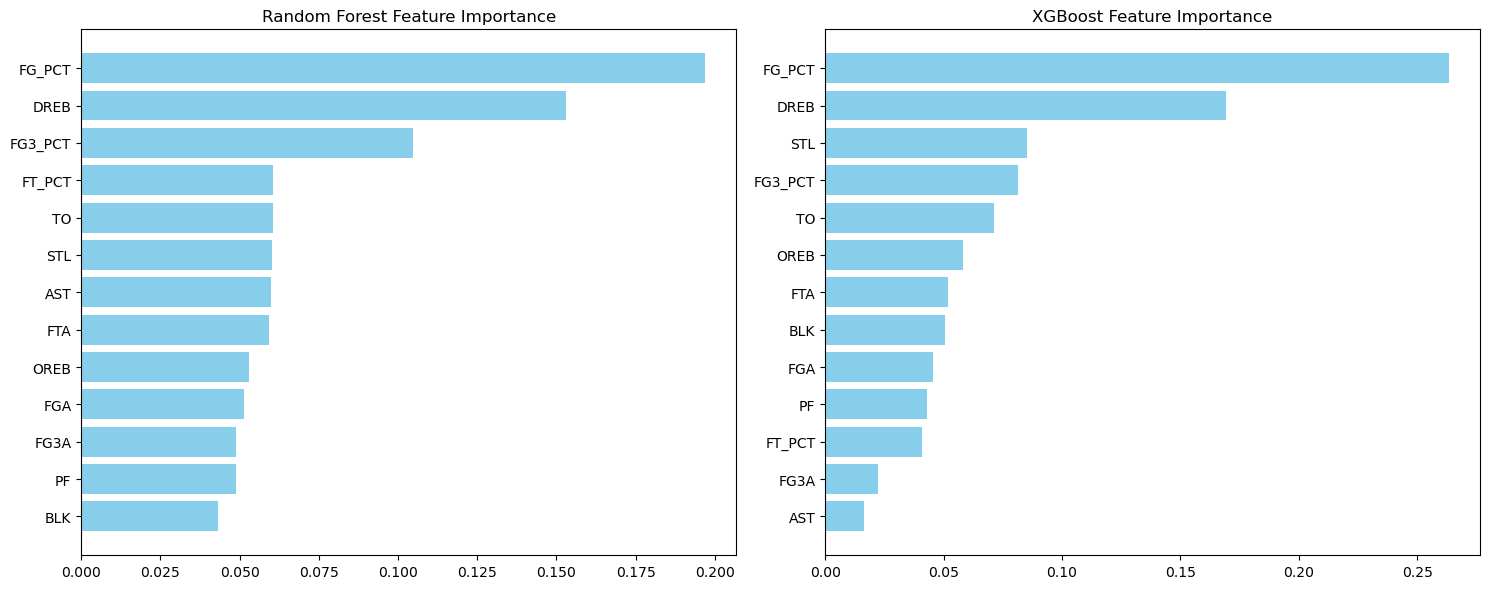

In [58]:
# graph feature importance
def plot_importance(model, title, ax):
    importances = model.feature_importances_
    indices = np.argsort(importances)
    
    ax.barh(range(len(indices)), importances[indices], align='center', color='skyblue')
    ax.set_yticks(range(len(indices)))
    ax.set_yticklabels([cols_to_multi[i] for i in indices])
    ax.set_title(title)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

plot_importance(rf_model, "Random Forest Feature Importance", ax1)
plot_importance(xgb_model, "XGBoost Feature Importance", ax2)

plt.tight_layout()
plt.show()

In [59]:
# check for overfitting in the model. Since training's accuracy is higher than test's, it is clea that the model is overfitting.
train_acc = best_model.score(X_train, y_train)
test_acc = best_model.score(X_test, y_test)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Training Accuracy: 0.8710
Test Accuracy: 0.8349


In [60]:
# use RandomizedSearchCV to reduce overfitting
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}
random_search = RandomizedSearchCV(
    estimator=xgb_model, 
    param_distributions=param_dist, 
    n_iter=10, 
    cv=skf, 
    scoring='accuracy', 
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)
best_xgb = random_search.best_estimator_
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best CV Score: {random_search.best_score_:.4f}")

Best Parameters: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV Score: 0.8379


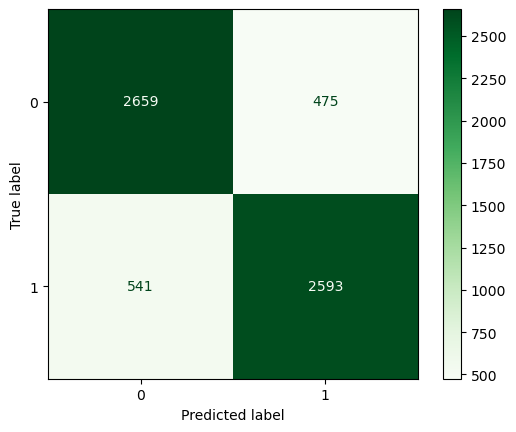

In [61]:
# confusion matrix after using RandomizedSearchCV. The model only reduced overfitting by a tiny amount.
# this means that we have reach the limit of this specific model with selected columns.
ConfusionMatrixDisplay.from_estimator(best_xgb, X_test, y_test, cmap='Greens')
plt.show()